In [43]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [44]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [45]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [46]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_dark_blue_to_pink = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(1.0)])

In [47]:
spin = 0.5
GAMMA = 2 * np.pi * 42.6e6
K = (3 / 2) * (cst.mu_0 / 4 / np.pi) ** 2 \
    * cst.hbar ** 2 * GAMMA ** 4 * spin * (1 + spin)  # m6 / s2

In [48]:
filename = "nmr-water-hewl-temp"
colors = cmap_dark_blue_to_pink(np.linspace(0, 1, 50))

WARNING, text_content specified without text_position 
WARNING, text_content specified without text_position 


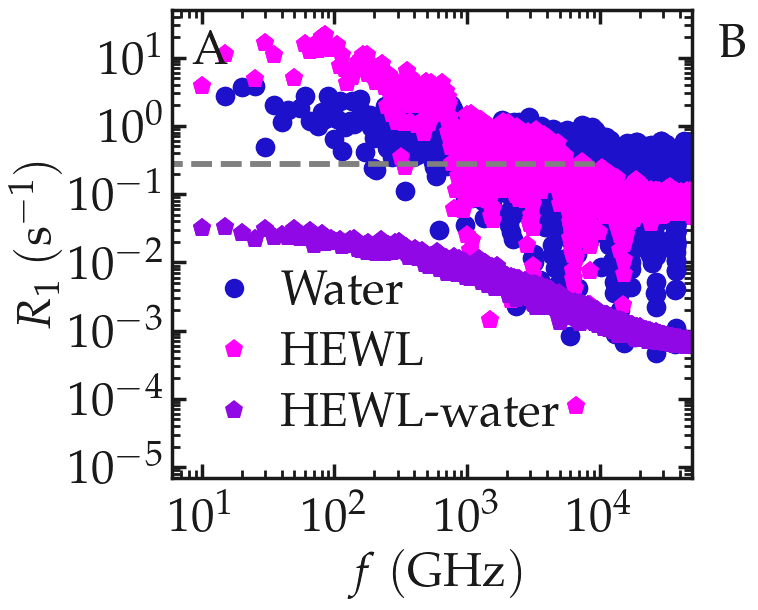

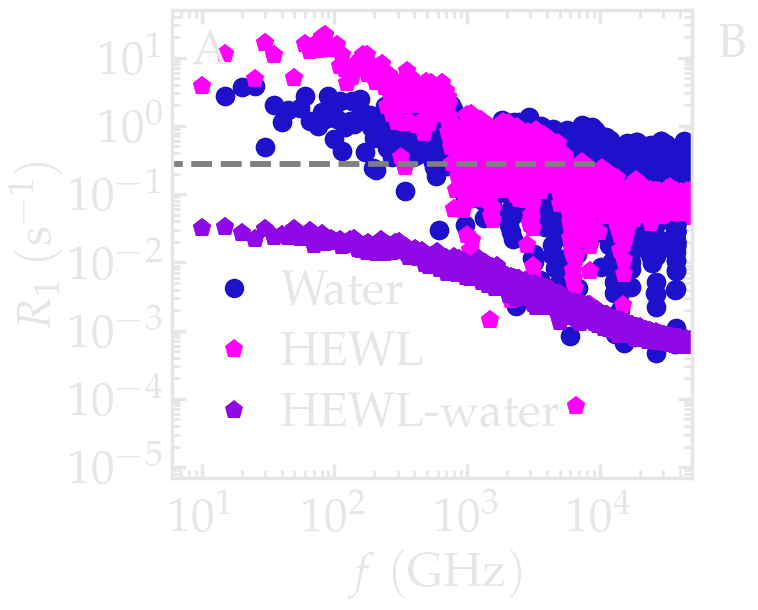

In [49]:
for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (13,6.2), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    myplt.add_panel()

    data_path = git_path + "/.submodules/dataset-protein-in-water/analysis/h2o/"
    data = np.load(data_path + "result5-0.npy", allow_pickle=True).item()
    R1 = data["R1"]; R1_err = data["R1_err"]; f = data["f"]
    myplt.add_plot(x = f, y = R1, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0], markersize = 14, data_label = r'Water')
    
    data_path = git_path + "/.submodules/dataset-protein-in-water/analysis/lys/"
    data = np.load(data_path + "result5-0.npy", allow_pickle=True).item()
    R1 = data["R1"]; R1_err = data["R1_err"]; f = data["f"]
    myplt.add_plot(x = f, y = R1, type = "loglog", linewidth_data = 3,
                marker = "p", data_color = colors[-1], markersize = 14, data_label = r'HEWL')
    
    data_path = git_path + "/.submodules/dataset-protein-in-water/analysis/h2o-lys/"
    data = np.load(data_path + "result5-0.npy", allow_pickle=True).item()
    R1 = data["R1"]; R1_err = data["R1_err"]; f = data["f"]
    myplt.add_plot(x = f, y = R1, type = "loglog", linewidth_data = 3,
                marker = "p", data_color = colors[25], markersize = 14, data_label = r'HEWL-water')

    x = np.linspace(5, 10000)
    myplt.add_plot(x = x, y = x * 0 + 1/3.588, type = "loglog", linewidth_data = 3,
                marker = "--", data_color = np.array([0.5, 0.5, 0.5]), markersize = 14) # , data_label = r'Bulk water')

    myplt.complete_panel(ylabel = r'$R_1~(\mathrm{s}^{-1})$', xlabel = r'$f~(\mathrm{GHz})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(6, 50000), y_boundaries=(0.000007, 50)) # , x_ticks = [40, 80, 120, 160])
   
    myplt.add_text(text_content = "B")
    myplt.add_text(text_position = [80000, 31])

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = filename, saving_path = git_path+path_figures)

In [50]:
from PIL import Image

right_padding = 950  # pixels of extra space

for i in [1, 2]:
    if i == 1:
        figure_path = "nmr-water-hewl-temp.png"
        insert_path = "snapshot-light.png"
        output_path = "nmr-water-hewl.png"
    else:
        figure_path = "nmr-water-hewl-temp-dm.png"
        insert_path = "snapshot-dark.png"
        output_path = "nmr-water-hewl-dm.png"

    figure = Image.open(figure_path).convert("RGBA")
    insert = Image.open(insert_path).convert("RGBA")

    # Create a larger canvas
    canvas = Image.new(
        "RGBA",
        (figure.width + right_padding, figure.height),
        (0, 0, 0, 0),
    )
    canvas.alpha_composite(figure, (0, 0))

    # # Start from the spectrum itself — preserves its own background/transparency
    # canvas = figure.copy()

    scale = 0.6
    target_w = int(figure.width * scale)
    target_h = int(insert.height * (target_w / insert.width))
    legend_resized = insert.resize((target_w, target_h), Image.LANCZOS)

    top_margin = 10
    lat_margin = 0
    x = figure.width + right_padding - target_w - lat_margin
    y = top_margin

    canvas.alpha_composite(legend_resized, (x, y))

    canvas.save(output_path)  # keep as PNG with alpha, don't convert to RGB
    print(f"Saved {output_path}")

Saved nmr-water-hewl.png
Saved nmr-water-hewl-dm.png
